In [2]:
!pip install xgboost

In [4]:
!pip install imbalanced-learn

### Knižnice ###

In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score
)

from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import RandomUnderSampler


### Data ###

In [224]:
#Načítanie dát zo súboru
data = pd.read_csv("data.csv")

target_col = "Bankrupt?"

#Rozdelenie dát
X = data.drop(columns=[target_col])
y = data[target_col]

#Rozdelenie dát na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#Výpočet váhy pre menšinovú triedu
base_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

#Vytvorenie váh pre jednotlivé záznamy
sample_weights = np.where(y_train == 1, base_scale_pos_weight, 1.0)


#Výpis rozmerov dát a vypočítanej váhy
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("base_scale_pos_weight:", base_scale_pos_weight)

Shape X_train: (5455, 95)
Shape X_test: (1364, 95)
base_scale_pos_weight: 29.994318181818183


### Baseline XGBoost ###

              precision    recall  f1-score   support

           0    0.98341   0.98788   0.98564      1320
           1    0.57895   0.50000   0.53659        44

    accuracy                        0.97214      1364
   macro avg    0.78118   0.74394   0.76111      1364
weighted avg    0.97036   0.97214   0.97115      1364



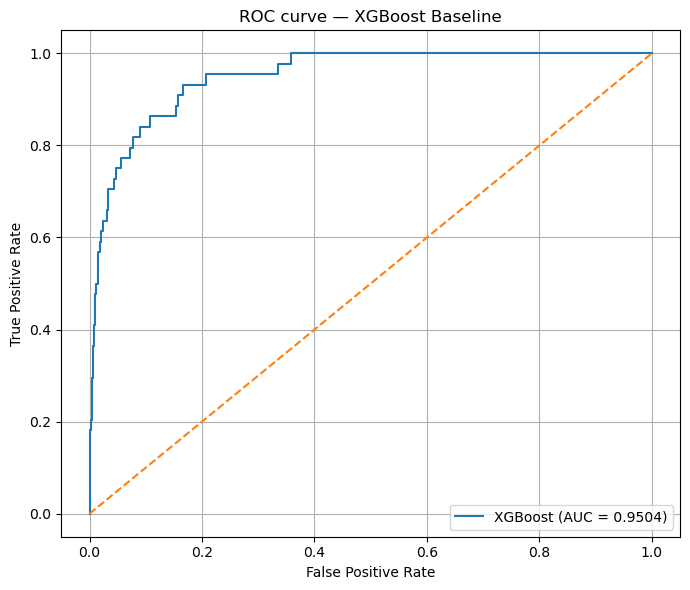

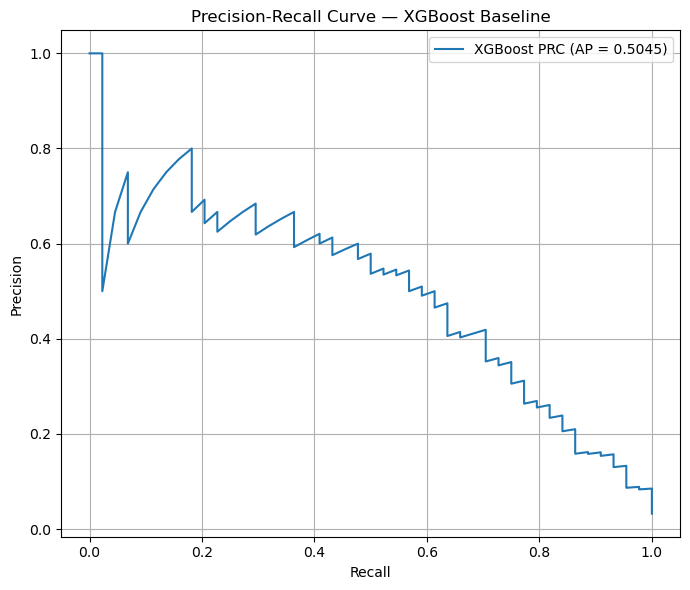

PRC AUC (Average Precision): 0.5045


<Figure size 640x480 with 0 Axes>

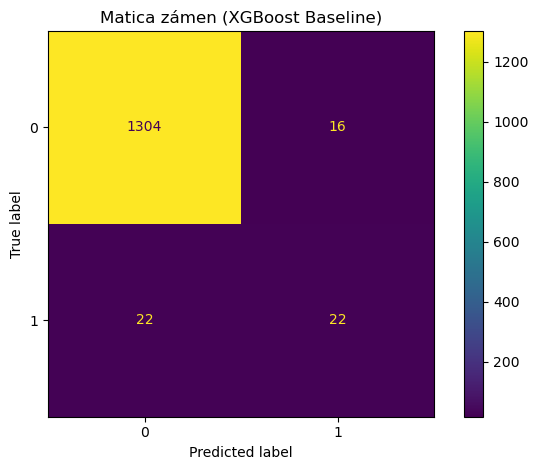

In [33]:
#Vytvorenie základného XGBoost modelu s váhou pre nevyvážené triedy
xgb1 = XGBClassifier(scale_pos_weight=base_scale_pos_weight)

#Trénovanie modelu na trénovacích dátach
xgb1.fit(X_train, y_train)

#Predikcia tried na testovacích dátach
y_pred1 = xgb1.predict(X_test)

#Predikcia pravdepodobnosti pre triedu 1
y_proba1 = xgb1.predict_proba(X_test)[:, 1]

#Výpis metrík klasifikácie
print(classification_report(y_test, y_pred1, digits=5))


#ROC krivka
fpr_xgb1, tpr_xgb1, _ = roc_curve(y_test, y_proba1)
roc_auc_xgb1 = auc(fpr_xgb1, tpr_xgb1)

plt.figure(figsize=(7, 6))
plt.plot(fpr_xgb1, tpr_xgb1, label=f"XGBoost (AUC = {roc_auc_xgb1:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — XGBoost Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
precisions_xgb1, recalls_xgb1, _ = precision_recall_curve(y_test, y_proba1)
prc_auc_xgb1 = average_precision_score(y_test, y_proba1)

plt.figure(figsize=(7, 6))
plt.plot(recalls_xgb1, precisions_xgb1, label=f"XGBoost PRC (AP = {prc_auc_xgb1:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc_xgb1:.4f}")


#Matica zámen
cm_xgb_baseline = confusion_matrix(y_test, y_pred1)
plt.figure()
ConfusionMatrixDisplay(cm_xgb_baseline).plot()
plt.title("Matica zámen (XGBoost Baseline)")
plt.tight_layout()
plt.show()

### Baseline XGBoost + SMOTE ###

Classification Report (Baseline XGBoost + SMOTE)
              precision    recall  f1-score   support

           0    0.98766   0.97045   0.97898      1320
           1    0.41791   0.63636   0.50450        44

    accuracy                        0.95968      1364
   macro avg    0.70279   0.80341   0.74174      1364
weighted avg    0.96928   0.95968   0.96368      1364


Confusion Matrix
[[1281   39]
 [  16   28]]


<Figure size 600x500 with 0 Axes>

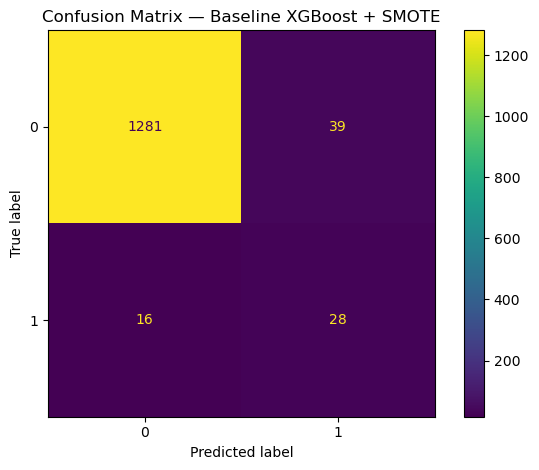

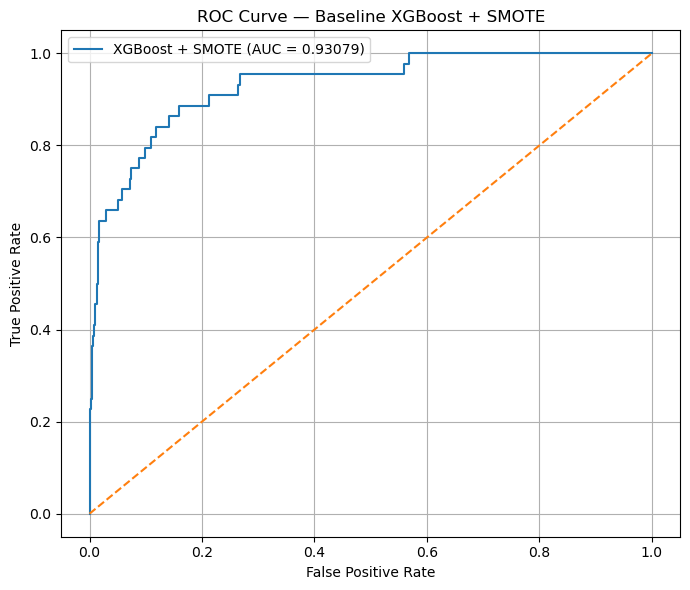

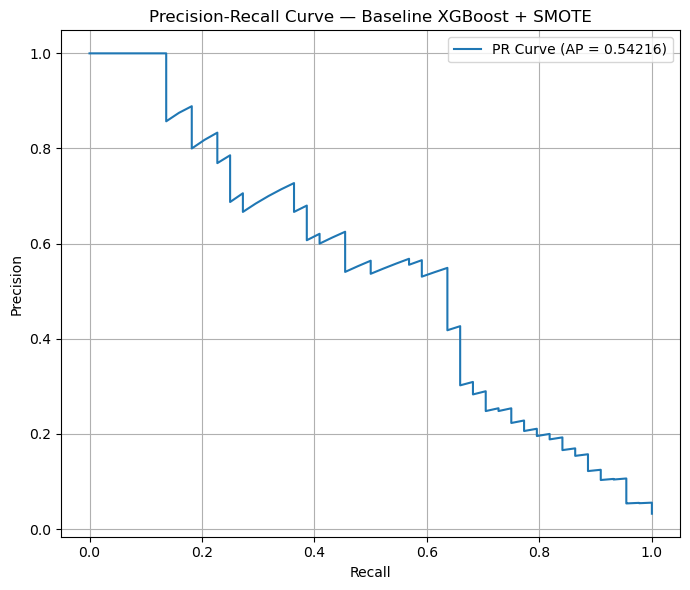

In [52]:
#Vytvorenie pipeline so SMOTE a XGBoost modelom
baseline_smote_xgb = ImbPipeline(steps=[
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            scale_pos_weight=base_scale_pos_weight
        )
    )
])

#Trénovanie pipeline na trénovacích dátach
baseline_smote_xgb.fit(X_train, y_train)

#Predikcia tried na testovacích dátach
y_pred2 = baseline_smote_xgb.predict(X_test)

#Predikcia pravdepodobnosti pre triedu 1
y_proba2 = baseline_smote_xgb.predict_proba(X_test)[:, 1]

#Výpis reportu klasifikácie
print("Classification Report (Baseline XGBoost + SMOTE)")
print(classification_report(y_test, y_pred2, digits=5))


roc_auc2 = roc_auc_score(y_test, y_proba2)
prc_auc2 = average_precision_score(y_test, y_proba2)

cm = confusion_matrix(y_test, y_pred2)

#Matica zámen
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Baseline XGBoost + SMOTE")
plt.tight_layout()
plt.show()


#ROC krivka
fpr2, tpr2, _ = roc_curve(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(fpr2, tpr2, label=f"XGBoost + SMOTE (AUC = {roc_auc2:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline XGBoost + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
precisions2, recalls2, _ = precision_recall_curve(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(recalls2, precisions2, label=f"PR Curve (AP = {prc_auc2:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline XGBoost + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Baseline XGBoost + ADASYN ###

Classification Report (Baseline XGBoost + ADASYN)
              precision    recall  f1-score   support

           0    0.98683   0.96515   0.97587      1320
           1    0.36986   0.61364   0.46154        44

    accuracy                        0.95381      1364
   macro avg    0.67835   0.78939   0.71870      1364
weighted avg    0.96693   0.95381   0.95928      1364


Confusion Matrix
[[1274   46]
 [  17   27]]


<Figure size 600x500 with 0 Axes>

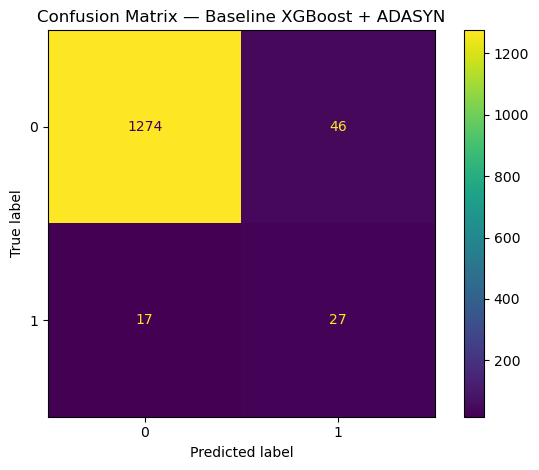

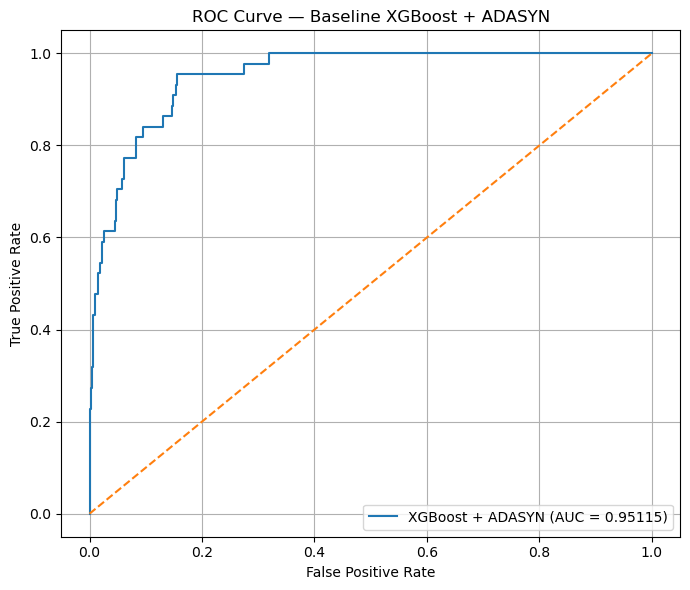

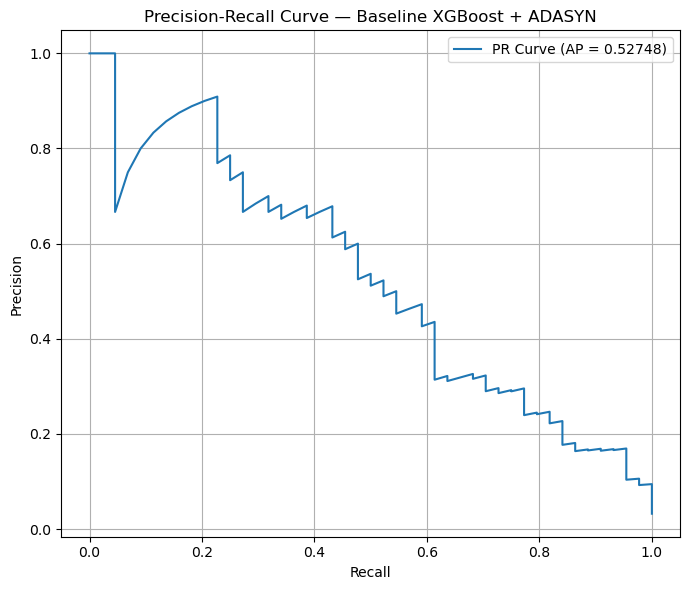

In [62]:
#Vytvorenie pipeline s ADASYN a XGBoost modelom
baseline_adasyn_xgb = ImbPipeline(steps=[
    (
        "adasyn",
        ADASYN(random_state=42)
    ),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            scale_pos_weight=base_scale_pos_weight
        )
    )
])

#Trénovanie modelu na trénovacích dátach
baseline_adasyn_xgb.fit(X_train, y_train)

#Predikcia tried na testovacích dátach
y_pred3 = baseline_adasyn_xgb.predict(X_test)

# Predikcia pravdepodobnosti pre triedu 1
y_proba3 = baseline_adasyn_xgb.predict_proba(X_test)[:, 1]


#Výpis reportu klasifikácie
print("Classification Report (Baseline XGBoost + ADASYN)")
print(classification_report(y_test, y_pred3, digits=5))

# Výpočet ROC AUC a PRC AUC metrík
roc_auc3 = roc_auc_score(y_test, y_proba3)
prc_auc3 = average_precision_score(y_test, y_proba3)


#Matica zámen
cm = confusion_matrix(y_test, y_pred3)

print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Baseline XGBoost + ADASYN")
plt.tight_layout()
plt.show()


#ROC krivka
fpr3, tpr3, _ = roc_curve(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(fpr3, tpr3, label=f"XGBoost + ADASYN (AUC = {roc_auc3:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline XGBoost + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
precisions3, recalls3, _ = precision_recall_curve(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(recalls3, precisions3, label=f"PR Curve (AP = {prc_auc3:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline XGBoost + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best params:
{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__scale_pos_weight': 1.5, 'smote__k_neighbors': 3, 'smote__sampling_strategy': 0.25, 'under__sampling_strategy': 0.08}
F1-score (CV): 0.4927

Threshold: 0.7305

Classification Report (XGBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0     0.9870    0.9803    0.9837      1320
           1     0.5094    0.6136    0.5567        44

    accuracy                         0.9685      1364
   macro avg     0.7482    0.7970    0.7702      1364
weighted avg     0.9716    0.9685    0.9699      1364


Confusion Matrix
[[1294   26]
 [  17   27]]


<Figure size 600x500 with 0 Axes>

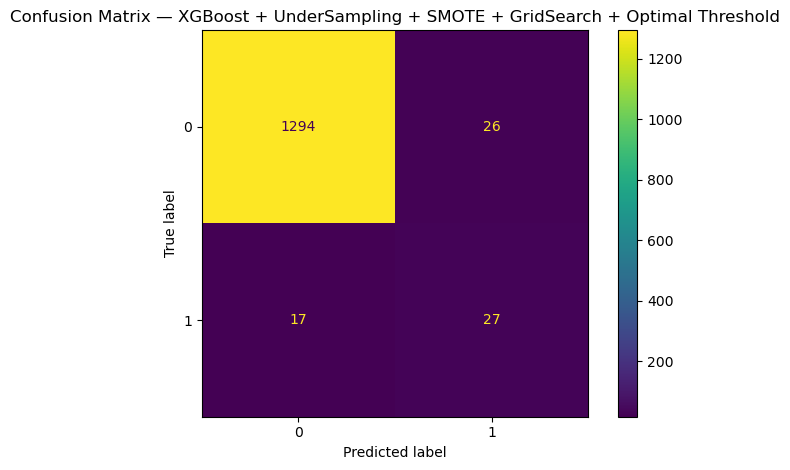

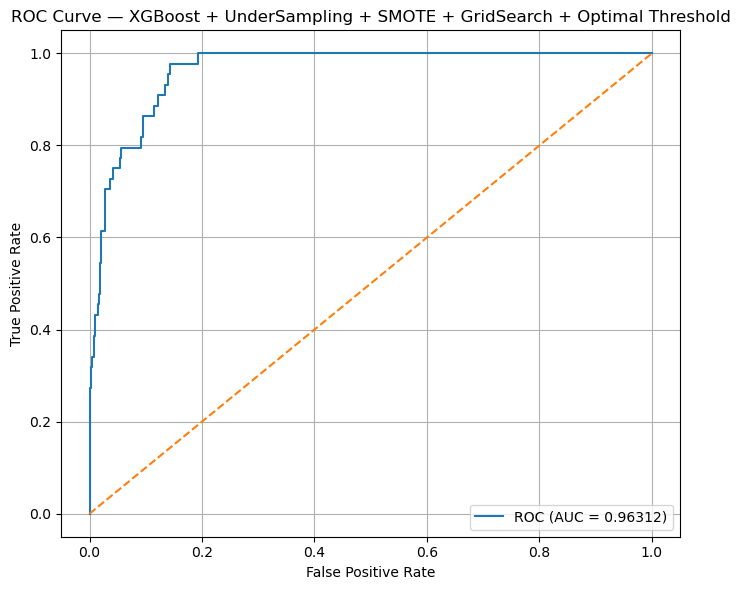

ROC AUC: 0.96312


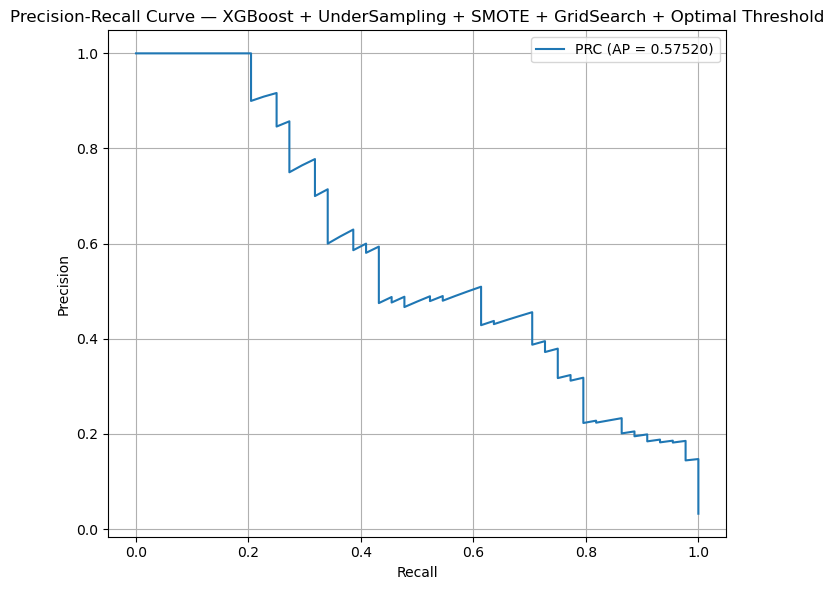

PRC AUC (Average Precision): 0.57520


In [100]:
#Vytvorenie pipeline s undersamplingom, SMOTE a XGBoost modelom
pipe = ImbPipeline(steps=[
    (
        "under",
        RandomUnderSampler(random_state=42)
    ),
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "model",
        XGBClassifier(
            eval_metric='aucpr',
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            n_estimators=400,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist"
        )
    )
])

#Definovanie rozsahu hyperparametrov pre GridSearch
param_grid = {
    'under__sampling_strategy': [0.05, 0.08],

    'smote__sampling_strategy': [0.25, 0.30, 0.35],
    'smote__k_neighbors': [3, 5],

    'model__max_depth': [4, 5, 6],
    'model__learning_rate': [0.03, 0.05],
    'model__scale_pos_weight': [1.5, 2.0]
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Definovanie hodnotiacej metriky F1-score
scorer = make_scorer(f1_score, pos_label=1)

#Nastavenie GridSearchCV pre hľadanie najlepších parametrov
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

#Spustenie trénovania a hľadania najlepšieho modelu
grid_search.fit(X_train, y_train)


#Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

#Uloženie najlepšieho modelu
best_model1 = grid_search.best_estimator_

#Výpočet pravdepodobností pre triedu 1
probs = best_model1.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

#Výpočet F1-score pre rôzne prahy
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)

#Výber prahu s najvyšším F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nThreshold: {best_threshold:.4f}")

#Predikcia tried podľa optimálneho prahu
y_pred_opt = (probs >= best_threshold).astype(int)

#Výpis reportu klasifikácie
print("\nClassification Report (XGBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred_opt, digits=4))

#Matica zámen
cm = confusion_matrix(y_test, y_pred_opt)
print("\nConfusion Matrix")
print(cm)
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — XGBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.5f}")


#Precision-Recall krivka
prc_auc = average_precision_score(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(recalls, precisions, label=f"PRC (AP = {prc_auc:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc:.5f}")

### XGBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best params:
{'adasyn__n_neighbors': 5, 'adasyn__sampling_strategy': 0.35, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__scale_pos_weight': 1.5, 'under__sampling_strategy': 0.05}
F1-score (CV): 0.4867

Threshold: 0.6136

Classification Report (XGBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0     0.9848    0.9841    0.9845      1320
           1     0.5333    0.5455    0.5393        44

    accuracy                         0.9699      1364
   macro avg     0.7591    0.7648    0.7619      1364
weighted avg     0.9703    0.9699    0.9701      1364


Confusion Matrix
[[1299   21]
 [  20   24]]


<Figure size 600x500 with 0 Axes>

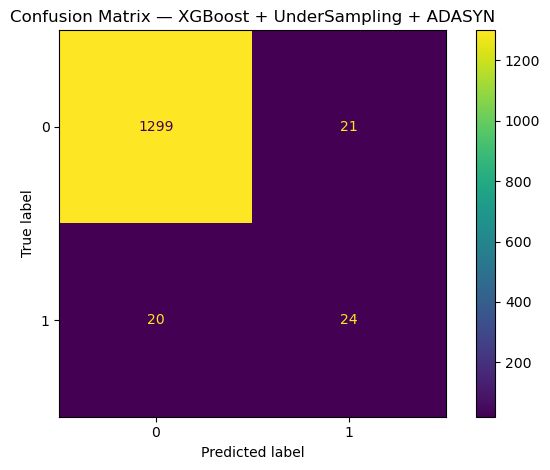

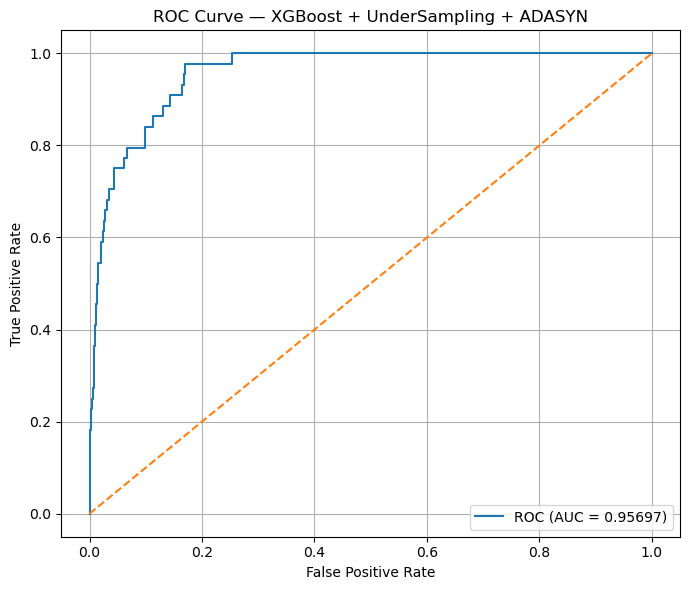

ROC AUC: 0.95697


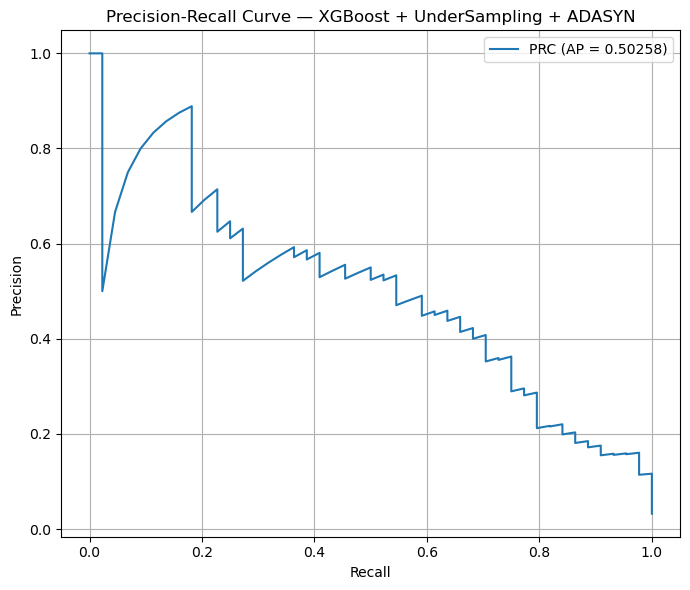

PRC AUC (Average Precision): 0.50258


In [126]:
from imblearn.over_sampling import ADASYN

#Vytvorenie pipeline s undersamplingom, ADASYN a XGBoost modelom
pipe = ImbPipeline(steps=[
    (
        "under",
        RandomUnderSampler(random_state=42)
    ),
    (
        "adasyn",
        ADASYN(random_state=42)
    ),
    (
        "model",
        XGBClassifier(
            eval_metric='aucpr',
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            n_estimators=400,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist"
        )
    )
])

#Definovanie hyperparametrov pre GridSearch
param_grid = {
    'under__sampling_strategy': [0.05, 0.08],

    'adasyn__sampling_strategy': [0.25, 0.30, 0.35],
    'adasyn__n_neighbors': [3, 5],

    'model__max_depth': [4, 5, 6],
    'model__learning_rate': [0.03, 0.05],
    'model__scale_pos_weight': [1.5, 2.0]
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nastavenie F1-score ako hodnotiacej metriky
scorer = make_scorer(f1_score, pos_label=1)

# Vytvorenie GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

# Trénovanie modelu a hľadanie najlepších parametrov
grid_search.fit(X_train, y_train)

# Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)

# Výpis najlepšieho F1-score z krížovej validácie
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

# Uloženie najlepšieho modelu
best_model = grid_search.best_estimator_

# Výpočet pravdepodobností pre triedu 1
probs = best_model.predict_proba(X_test)[:, 1]

# Výpočet hodnôt pre Precision-Recall krivku
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

# Výpočet F1-score pre rôzne prahy
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)

# Výber najlepšieho prahu podľa F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# Výpis optimálneho prahu
print(f"\nThreshold: {best_threshold:.4f}")

# Predikcia tried podľa optimálneho prahu
y_pred_opt2 = (probs >= best_threshold).astype(int)

#Výpis reportu klasifikácie
print("\nClassification Report (XGBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred_opt2, digits=4))

#Matica zámen
cm = confusion_matrix(y_test, y_pred_opt2)
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — XGBoost + UnderSampling + ADASYN")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost + UnderSampling + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.5f}")

#Precision-Recall krivka
prc_auc = average_precision_score(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(recalls, precisions, label=f"PRC (AP = {prc_auc:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost + UnderSampling + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc:.5f}")

### Výsledky všetkých modelov ###

In [102]:
print("Baseline XGBoost")
print(classification_report(y_test, y_pred1))


print("\nBaseline XGBoost + SMOTE")
print(classification_report(y_test, y_pred2))


print("\nBaseline XGBoost + ADASYN")
print(classification_report(y_test, y_pred3))


print("\nXGBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
print(classification_report(y_test, y_pred_opt))


print("\nXGBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
print(classification_report(y_test, y_pred_opt2))



Baseline XGBoost
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1320
           1       0.58      0.50      0.54        44

    accuracy                           0.97      1364
   macro avg       0.78      0.74      0.76      1364
weighted avg       0.97      0.97      0.97      1364


Baseline XGBoost + SMOTE
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.42      0.64      0.50        44

    accuracy                           0.96      1364
   macro avg       0.70      0.80      0.74      1364
weighted avg       0.97      0.96      0.96      1364


Baseline XGBoost + ADASYN
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.37      0.61      0.46        44

    accuracy                           0.95      1364
   macro avg       0.68      0.79      0.72      1364
weig

### Permutation importance ###

                                              feature  importance
9                Continuous interest rate (after tax)    0.154545
35                         Total debt/Total net worth    0.122727
39                               Borrowing dependency    0.059091
33                                        Quick Ratio    0.050000
18            Persistent EPS in the Last Four Seasons    0.045455
8         Non-industry income and expenditure/revenue    0.031818
67                  Retained Earnings to Total Assets    0.022727
12                                     Cash flow rate    0.018182
2    ROA(B) before interest and depreciation after...    0.018182
60                       Operating Funds to Liability    0.018182


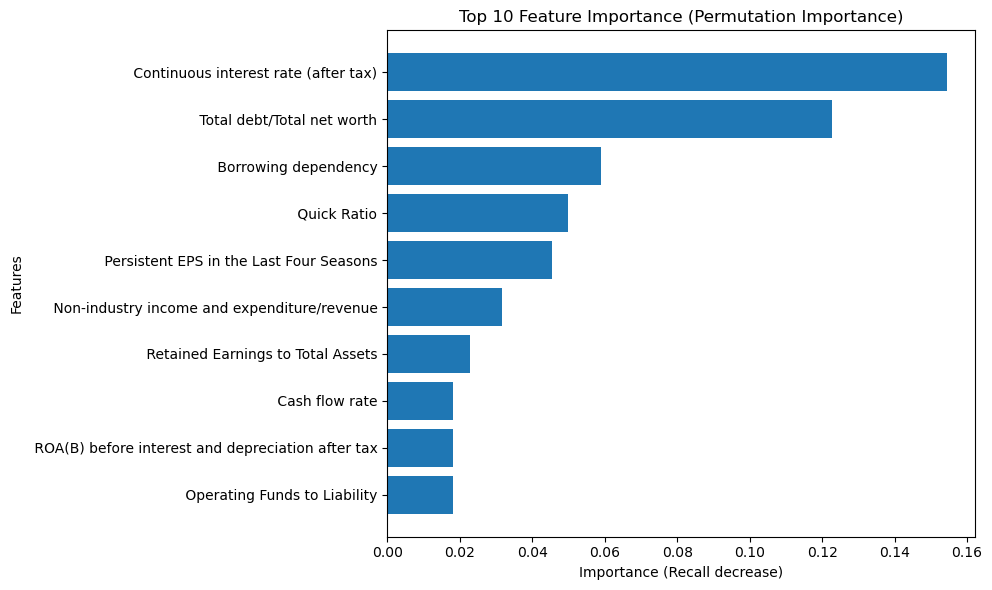

In [104]:
#Vytvorenie kópie testovacích dát
X_test_imp = X_test.copy()

#Výpočet permutation importance pre najlepší model
result = permutation_importance(
    best_model1["model"],
    X_test_imp,
    y_test,
    scoring="recall",         
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

#Vytvorenie tabuľky s dôležitosťou premenných
importance_df = pd.DataFrame({
    "feature": X_test_imp.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

#Výpis 10 najdôležitejších premenných
print(importance_df.head(10))

#Výber 10 najdôležitejších premenných
top10 = importance_df.head(10)

#Vykreslenie grafu dôležitosti premenných
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance (Permutation Importance)")
plt.xlabel("Importance (Recall decrease)")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

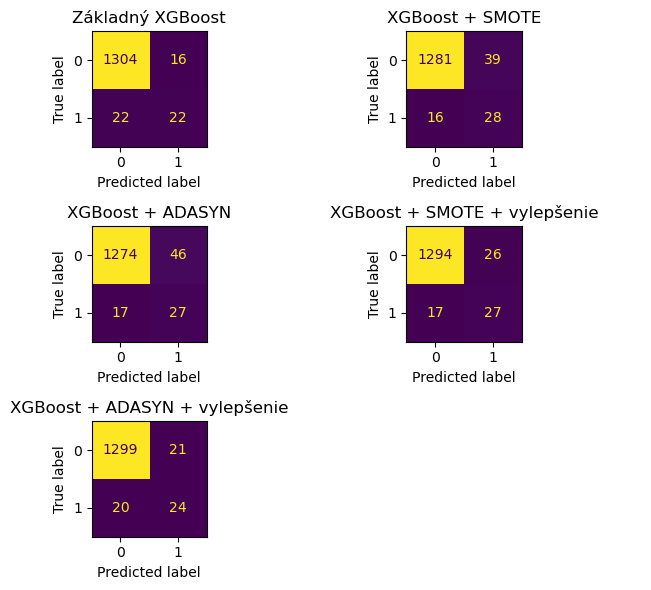

In [141]:
fig, axes = plt.subplots(3, 2, figsize=(7, 6))

cm1 = confusion_matrix(y_test, y_pred1)
ConfusionMatrixDisplay(cm1).plot(ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Základný XGBoost")

cm2 = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm2).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title("XGBoost + SMOTE")

cm3 = confusion_matrix(y_test, y_pred3)
ConfusionMatrixDisplay(cm3).plot(ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("XGBoost + ADASYN")

cm4 = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm4).plot(ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("XGBoost + SMOTE + vylepšenie")

cm5 = confusion_matrix(y_test, y_pred_opt2)
ConfusionMatrixDisplay(cm5).plot(ax=axes[2, 0], colorbar=False)
axes[2, 0].set_title("XGBoost + ADASYN + vylepšenie")

axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

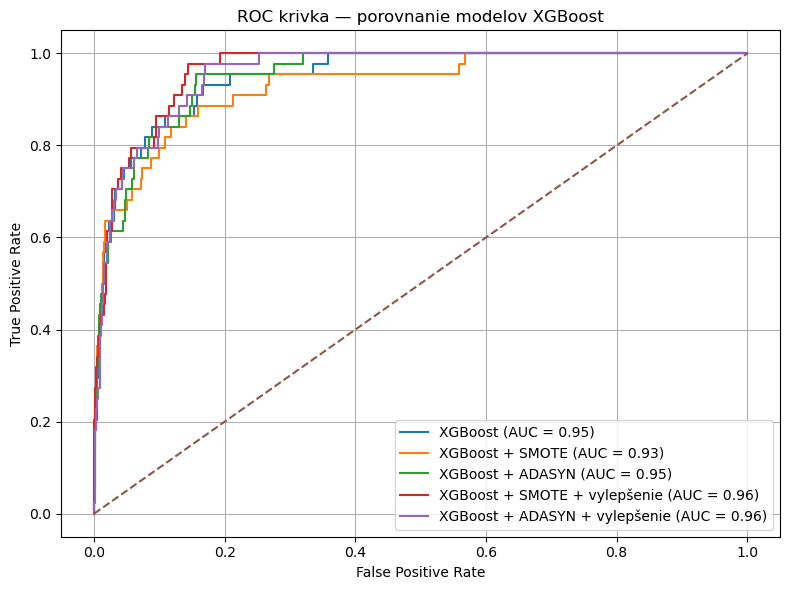

In [161]:
fpr1, tpr1, _ = roc_curve(y_test, y_proba1)
roc_auc1 = roc_auc_score(y_test, y_proba1)

fpr2, tpr2, _ = roc_curve(y_test, y_proba2)
roc_auc2 = roc_auc_score(y_test, y_proba2)

fpr3, tpr3, _ = roc_curve(y_test, y_proba3)
roc_auc3 = roc_auc_score(y_test, y_proba3)

y_proba4 = best_model1.predict_proba(X_test)[:, 1]
fpr4, tpr4, _ = roc_curve(y_test, y_proba4)
roc_auc4 = roc_auc_score(y_test, y_proba4)

y_proba5 = best_model.predict_proba(X_test)[:, 1]
fpr5, tpr5, _ = roc_curve(y_test, y_proba5)
roc_auc5 = roc_auc_score(y_test, y_proba5)

plt.figure(figsize=(8, 6))

plt.plot(fpr1, tpr1, label=f"XGBoost (AUC = {roc_auc1:.2f})")
plt.plot(fpr2, tpr2, label=f"XGBoost + SMOTE (AUC = {roc_auc2:.2f})")
plt.plot(fpr3, tpr3, label=f"XGBoost + ADASYN (AUC = {roc_auc3:.2f})")
plt.plot(fpr4, tpr4, label=f"XGBoost + SMOTE + vylepšenie (AUC = {roc_auc4:.2f})")
plt.plot(fpr5, tpr5, label=f"XGBoost + ADASYN + vylepšenie (AUC = {roc_auc5:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krivka — porovnanie modelov XGBoost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

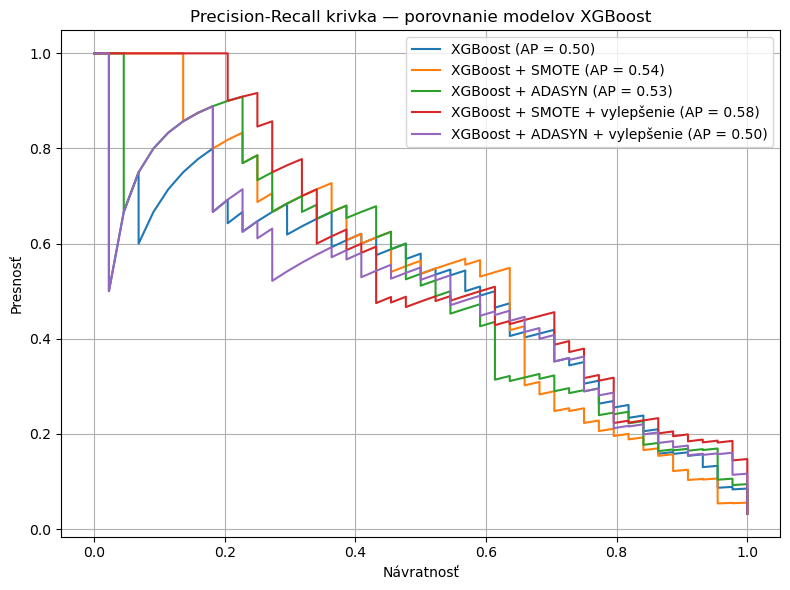

In [159]:
prec1, rec1, _ = precision_recall_curve(y_test, y_proba1)
ap1 = average_precision_score(y_test, y_proba1)

prec2, rec2, _ = precision_recall_curve(y_test, y_proba2)
ap2 = average_precision_score(y_test, y_proba2)

prec3, rec3, _ = precision_recall_curve(y_test, y_proba3)
ap3 = average_precision_score(y_test, y_proba3)

y_proba4 = best_model1.predict_proba(X_test)[:, 1]
prec4, rec4, _ = precision_recall_curve(y_test, y_proba4)
ap4 = average_precision_score(y_test, y_proba4)

y_proba5 = best_model.predict_proba(X_test)[:, 1]
prec5, rec5, _ = precision_recall_curve(y_test, y_proba5)
ap5 = average_precision_score(y_test, y_proba5)

plt.figure(figsize=(8, 6))

plt.plot(rec1, prec1, label=f"XGBoost (AP = {ap1:.2f})")
plt.plot(rec2, prec2, label=f"XGBoost + SMOTE (AP = {ap2:.2f})")
plt.plot(rec3, prec3, label=f"XGBoost + ADASYN (AP = {ap3:.2f})")
plt.plot(rec4, prec4, label=f"XGBoost + SMOTE + vylepšenie (AP = {ap4:.2f})")
plt.plot(rec5, prec5, label=f"XGBoost + ADASYN + vylepšenie (AP = {ap5:.2f})")

plt.xlabel("Návratnosť")
plt.ylabel("Presnosť")
plt.title("Precision-Recall krivka — porovnanie modelov XGBoost")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()